In [3]:
!pip uninstall numpy -y

In [1]:
!pip install --upgrade bertopic sentence-transformers spacy torch torchvision torchaudio nltk scikit-learn pandas umap-learn hdbscan pymorphy2 numpy==1.26.4

Подготовка. Загрузка и извлечение файла. (ЭТА И СЛЕДУЮЩАЯ ЯЧЕЙКА ТОЛЬКО ДЛЯ GOOGLE COLAB)

In [ ]:
from google.colab import files # выбор zip архива со всеми статьями
uploaded = files.upload()

In [ ]:
import zipfile
import io

zip_file_name = "articles.zip" # здесь должно быть написано имя загруженного файла
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), "r") as archive_object:
    archive_object.extractall("extracted_data") # в папку extracted_data будут помещены файлы из загруженного архива

Шаг I. Составление списка из статей и списка из номеров выпусков

In [3]:
import os
import re

vol_folder = "C:/Users/Евгений/Desktop/Проект/готовые к анализу"  # путь к папке с томами. Для google colab будет "extracted_data/вообще все тексты"

texts_list = []          # Список строк, который будет содержать все тексты
vol_issue_list = []    # Список строк, который будет содержать номер тома и выпуск для каждого текста

for individual_vol in sorted(os.listdir(vol_folder)): # каждый отдельный том, который находится в папке томов, будет обрабатываться в цикле
    vol_folder_path = os.path.join(vol_folder, individual_vol) # создаём переменную для пути к папке тома

    for individual_number in os.listdir(vol_folder_path): # каждый отдельный выпуск, который находится в папке отдельного тома, будет обрабатываться в цикле
        num_folder_path = os.path.join(vol_folder_path, individual_number) # создаём переменную для пути к папке выпуска

        for individual_article in os.listdir(num_folder_path): # каждая отдельная статья, которая находится в папке отдельного выпуска, будет обрабатываться в цикле
              art_path = os.path.join(num_folder_path, individual_article) # создаём переменную для пути к статье
              with open(art_path, "r", encoding = "utf-8") as f:
                  texts_list.append(f.read()) # добавляем текст из файла в список строк со всеми текстами
              vol_issue_list.append(individual_number) # добавляем название папки выпуска в список с информацией о томах и выпусках

print(f"Количество статей: {len(texts_list)}")
print(f"Указано выпусков для {len(vol_issue_list)} статей")

Количество статей: 1629
Указано выпусков для 1629 статей


Шаг II. Использование BERT для подготовки эмбеддингов

In [11]:
import torch
from sentence_transformers import SentenceTransformer

In [7]:
%%time
model_name = "ai-forever/sbert_large_nlu_ru" # имя используемой модели

if "model" not in globals() or model is None: # чтобы избежать повторной загрузки модели, если она уже загружена, проверяем, есть ли она
    device_for_bert = torch.device("cuda" if torch.cuda.is_available() else "cpu") # определяем, при помощи чего будут производиться рассчёты
    model = SentenceTransformer(model_name, device=device_for_bert) # загружаем модель

if "saved_embeddings" in globals() and saved_embeddings is not None and hasattr(saved_embeddings, "shape") and len(saved_embeddings) == len(texts_list):

    embeddings_ready = saved_embeddings # если уже есть сохранённые эмбеддинги, то просто оставляем их, чтобы рассчёты не производились заново
else:
    embeddings_ready = model.encode(texts_list, show_progress_bar=True) # рассчиваем эмбеддинги
    globals()["saved_embeddings"] = embeddings_ready # сохраняем эмбеддинги в глобальную переменную, чтобы потом не пришлось рассчитывать их

Batches:   0%|          | 0/51 [00:00<?, ?it/s]

CPU times: total: 3h 4min 50s
Wall time: 25min 34s


Шаг III. Подготовка к использованию BERTopic (лемматизация и токенизация)

In [13]:
import spacy
import nltk
from nltk.corpus import stopwords
import re
from sklearn.feature_extraction.text import CountVectorizer
!python -m spacy download ru_core_news_sm --quiet
nltk.download("stopwords")

[+] Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Евгений\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
import gc
russian_stopwords = stopwords.words("russian")
custom_stopwords = [
    "это", "мочь", "свой", "являться", "быть", "весь", "еще", "также",
    "очень", "именно", "который", "данный", "просто", "такой", "однако",
    "поэтому", "которые", "иметь",
    "статья", "текст", "автор", "работа", "исследование", "вопрос", "проблема",
    "наука", "философия", "научный", "знание", "теория", "человек", "мир", "проблема", "новый",
    "должный", "наш", "отношение", "философский", "александр", "познание", "случай",
    "не", "на", "что", "как", "по", "для", "или", "из", "то", "но", "мы", "это", "он", "его", "если", "бы", "же"
]
russian_stopwords.extend(custom_stopwords)
russian_stopwords = list(set(russian_stopwords)) # получаем список стоп-слов, куда были добавлены отдельно нужные стоп-слова

nlp_spacy = spacy.load("ru_core_news_sm", disable=["parser", "ner"]) # загружаем малую модель SpaCy

def spacy_tokenizer(text_input): # создаём функцию для токенизации
    lemmatized_text = []
    chunks = (text_input[i:i + 500_000] for i in range(0, len(text_input), 500_000))
    for chunk_text in chunks:
        chunk_text = re.sub(r"[^\w\s]", " ", chunk_text.lower())
        chunk_text = re.sub(r"\s+", " ", chunk_text).strip()
        doc = nlp_spacy(chunk_text) # применяем языковую модель к очищенному кусочку текста
        lemmas_chunks = [token.lemma_ for token in doc if not token.is_punct and not token.is_space and token.lemma_ not in russian_stopwords and len(token.lemma_) > 2 and re.fullmatch(r'[а-яёА-ЯЁ-]+', token.lemma_)] # проводим лемматизацию
        lemmatized_text.extend(lemmas_chunks)
        del chunk_text
        gc.collect()
    return lemmatized_text


vectorizer = CountVectorizer(tokenizer = spacy_tokenizer, ngram_range = (1, 3), max_df = 0.75, min_df = 2, max_features = 15000) # получаем векторизатор, который будет использоваться BERTopic
print(f"Векторизатор получен")

Векторизатор получен


Шаг IV. Использование BERTopic

In [149]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

In [151]:
custom_umap_model = UMAP( # описываем модель UMAP, нужную для сжатия эмбеддингов
    n_neighbors = 8,
    n_components = 10,
    min_dist = 0.2,
    metric = "cosine",
    random_state = 47,
)

custom_hdbscan_model = HDBSCAN(
    min_cluster_size = 12,
    min_samples = 4,
    cluster_selection_method = "eom",
    prediction_data = True
)

model_ready = BERTopic( # применяем BERTopic
    umap_model = custom_umap_model,
    hdbscan_model = custom_hdbscan_model,
    vectorizer_model = vectorizer,
    min_topic_size = 10,
    language = "russian",
    embedding_model = model,
    calculate_probabilities = True,
    verbose = True,
    nr_topics = "auto"
)

print("Объект BERTopic создан")

Объект BERTopic создан


Обучение BERTopic

In [153]:
%%time
initial_topics, initial_probabilities = model_ready.fit_transform(
    texts_list,
    embeddings = embeddings_ready
    )
print("Модель BERTopic обучена")

2025-06-25 03:48:05,178 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-25 03:48:10,012 - BERTopic - Dimensionality - Completed ✓
2025-06-25 03:48:10,012 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-25 03:48:10,130 - BERTopic - Cluster - Completed ✓
2025-06-25 03:48:10,130 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-06-25 04:16:23,731 - BERTopic - Representation - Completed ✓
2025-06-25 04:16:23,731 - BERTopic - Topic reduction - Reducing number of topics
2025-06-25 04:16:23,731 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-25 04:44:48,537 - BERTopic - Representation - Completed ✓
2025-06-25 04:44:48,544 - BERTopic - Topic reduction - Reduced number of topics from 3 to 3


Модель BERTopic обучена
CPU times: total: 1h 5min 16s
Wall time: 1h 7min 4s


Шаг V. Анализ найденных тем

In [159]:
if "model_ready" in globals() and hasattr(model_ready, "topics_") and model_ready.topics_ is not None:

    topic_info_df = model_ready.get_topic_info() # создаётся датафрейм с информацией о темах

    if not topic_info_df.empty:
        print("Общая информация о найденных темах:")
        print(topic_info_df[["Topic", "Count", "Name"]]) # выводим тему, количество статей, которые отнеслись к теме и автосгенерированное название темы

        print("\nКлючевые слова для каждой темы:")
        for index, row in topic_info_df.iterrows():
            topic_id = row["Topic"] # переменная для номера темы

            keywords_for_topic = model_ready.get_topic(topic_id) # получаем ключевые слова и выводим их в переменную

            print(f"\nТема {topic_id} (Статей: {row["Count"]}):")
            for word, score in keywords_for_topic[:10]: # цикл для первых 10 ключевых слов
                print(f"  - '{word}' ({score:.4f})") # выводим слово и важность слова
else:
    print("Модель не найдена или не обучена")

Общая информация о найденных темах:
   Topic  Count                               Name
0     -1      8                             -1____
1      0   1578    0_социальный_понятие_язык_смысл
2      1     43  1_год_институт_журнал_редколлегия

Ключевые слова для каждой темы:

Тема -1 (Статей: 8):
  - '' (0.0000)
  - '' (0.0000)
  - '' (0.0000)
  - '' (0.0000)
  - '' (0.0000)
  - '' (0.0000)
  - '' (0.0000)
  - '' (0.0000)
  - '' (0.0000)
  - '' (0.0000)

Тема 0 (Статей: 1578):
  - 'социальный' (0.0241)
  - 'понятие' (0.0221)
  - 'язык' (0.0219)
  - 'смысл' (0.0214)
  - 'образ' (0.0211)
  - 'объект' (0.0210)
  - 'время' (0.0205)
  - 'система' (0.0188)
  - 'идея' (0.0185)
  - 'процесс' (0.0180)

Тема 1 (Статей: 43):
  - 'год' (0.0461)
  - 'институт' (0.0364)
  - 'журнал' (0.0338)
  - 'редколлегия' (0.0295)
  - 'российский' (0.0274)
  - 'коллега' (0.0237)
  - 'член' (0.0227)
  - 'эпистемология' (0.0221)
  - 'владимир' (0.0217)
  - 'факультет' (0.0198)


Шаг VI. Эволюция тем во времени

ВИЗУАЛИЗАЦИЯ

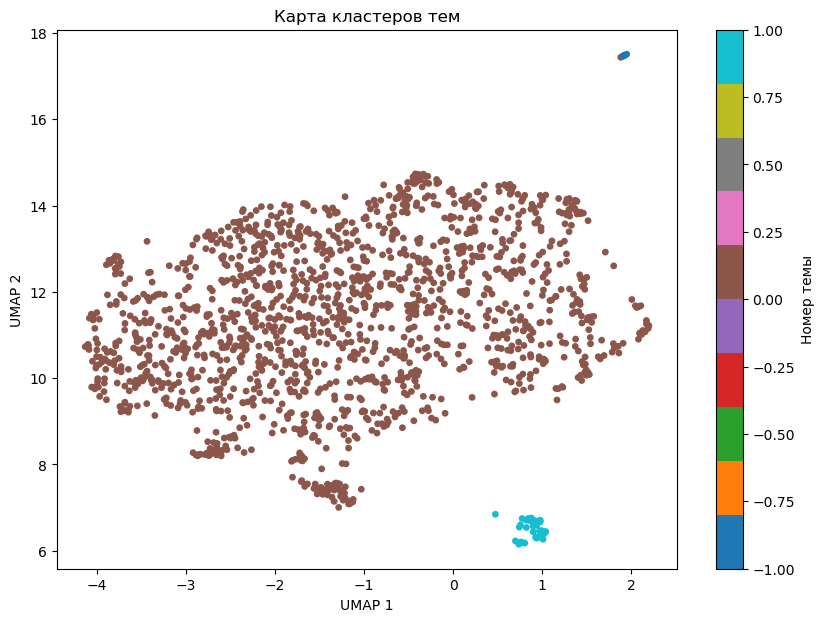

In [161]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

from umap import UMAP
umap_model = UMAP(n_components = 2, random_state = 47)
embeddings_2d = umap_model.fit_transform(embeddings_ready)

topic_nums = np.array(initial_topics)

plt.figure(figsize = (10, 7))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=topic_nums, cmap='tab10', s=15)
plt.title("Карта кластеров тем")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label = "Номер темы")
plt.show()

РАЗБИВАЕМ БОЛЬШОЙ КЛАСТЕР

In [163]:
texts_topic_0 = [text for i, text in enumerate(texts_list) if initial_topics[i] == 0] # выбираем тексты, которые относятся к теме 0
embeddings_topic_0 = [emb for i, emb in enumerate(embeddings_ready) if initial_topics[i] == 0] # выбираем их эмбеддинги

from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

custom_umap_model_0 = UMAP( # описываем модель UMAP, нужную для сжатия эмбеддингов
    n_neighbors = 8,
    n_components = 10,
    min_dist = 0.2,
    metric = "cosine",
    random_state = 47,
)

custom_hdbscan_model_0 = HDBSCAN(
    min_cluster_size = 12,
    min_samples = 4,
    cluster_selection_method = "eom",
    prediction_data = True
)

model_ready_0 = BERTopic( # применяем BERTopic
    umap_model = custom_umap_model_0,
    hdbscan_model = custom_hdbscan_model_0,
    vectorizer_model = vectorizer,
    min_topic_size = 10,
    language = "russian",
    embedding_model = model,
    calculate_probabilities = True,
    verbose = True,
    nr_topics = "auto"
)

print("Объект BERTopic для темы 0 создан")

Объект BERTopic для темы 0 создан


In [165]:
%%time
topics_0, probabilities_0 = model_ready_0.fit_transform(
    texts_topic_0,
    embeddings = np.array(embeddings_topic_0)
    )
print("Модель BERTopic обучена")

2025-06-25 04:58:47,081 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-25 04:58:51,737 - BERTopic - Dimensionality - Completed ✓
2025-06-25 04:58:51,738 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-25 04:58:51,909 - BERTopic - Cluster - Completed ✓
2025-06-25 04:58:51,910 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-06-25 05:27:01,321 - BERTopic - Representation - Completed ✓
2025-06-25 05:27:01,327 - BERTopic - Topic reduction - Reducing number of topics
2025-06-25 05:27:01,337 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-25 05:55:07,732 - BERTopic - Representation - Completed ✓
2025-06-25 05:55:07,732 - BERTopic - Topic reduction - Reduced number of topics from 31 to 24


Модель BERTopic обучена
CPU times: total: 1h 23min 59s
Wall time: 1h 26min 31s


In [167]:
if "model_ready_0" in globals() and hasattr(model_ready, "topics_") and model_ready_0.topics_ is not None:

    topic_info_df = model_ready_0.get_topic_info() # создаётся датафрейм с информацией о темах

    if not topic_info_df.empty:
        print("Общая информация о найденных темах:")
        print(topic_info_df[["Topic", "Count", "Name"]]) # выводим тему, количество статей, которые отнеслись к теме и автосгенерированное название темы

        print("\nКлючевые слова для каждой темы:")
        for index, row in topic_info_df.iterrows():
            topic_id = row['Topic'] # переменная для номера темы

            keywords_for_topic = model_ready_0.get_topic(topic_id) # получаем ключевые слова и выводим их в переменную

            print(f"\nТема {topic_id} (Статей: {row["Count"]}):")
            for word, score in keywords_for_topic[:10]: # цикл для первых 10 ключевых слов
                print(f"  - '{word}' ({score:.4f})") # выводим слово и важность слова
else:
    print("Модель не найдена или не обучена")

Общая информация о найденных темах:
    Topic  Count                                               Name
0      -1    600  -1_маркс_дисциплинарный_оценка техника_техноло...
1       0    215  0_чудо_повседневность_конструктивизм_социальны...
2       1    181        1_пропозиция_референция_предикат_дескрипция
3       2     78       2_зона_зона обмен_технологический_технонауки
4       3     56  3_феноменальный_квалиа_жест_феноменальный каче...
5       4     53  4_докладчик_секция_искусственный интеллект_сем...
6       5     53         5_кружок_венский_венский кружок_гейзенберг
7       6     40    6_рорти_прагматизм_симметрия_квантовый механика
8       7     38  7_исторический эпистемология_историзм_историог...
9       8     34  8_аспирант_виртуальный_виртуальный реальность_...
10      9     30                          9_шпет_лавров_шпета_зенон
11     10     19                        10_реформа_рана_уклад_рынок
12     11     19                 11_бэкона_бэкон_фейерабенда_хьюэлл
13     12   

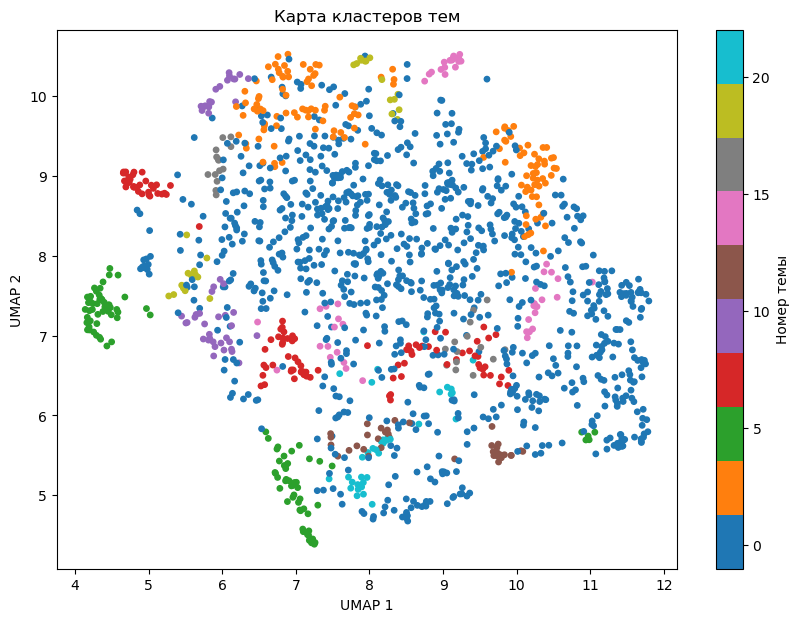

In [169]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

from umap import UMAP
umap_model = UMAP(n_components = 2, random_state = 47)
embeddings_2d = umap_model.fit_transform(embeddings_topic_0)

topic_nums = np.array(topics_0)

plt.figure(figsize = (10, 7))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c = topic_nums, cmap = 'tab10', s = 15)
plt.title("Карта кластеров тем")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label = "Номер темы")
plt.show()

Делаем визуализацию для отобранных нами тем

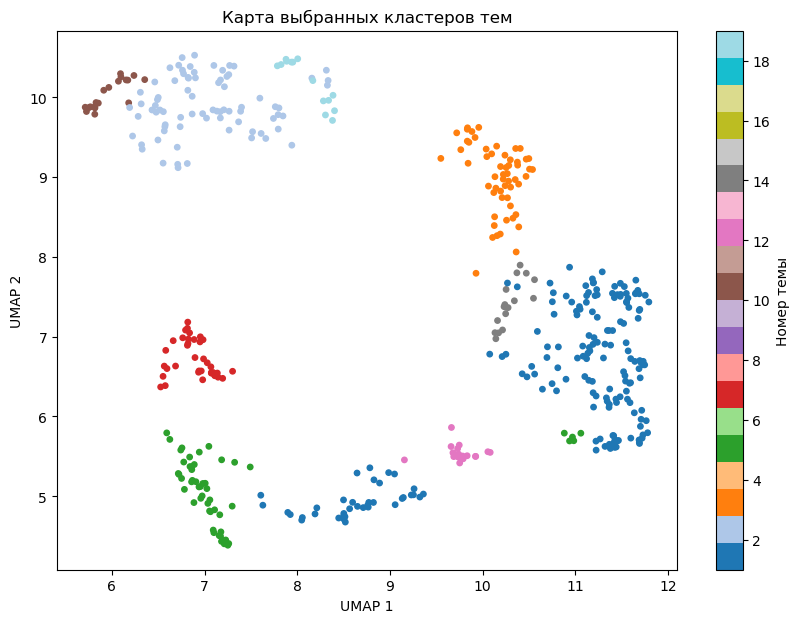

In [171]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

from umap import UMAP
umap_model = UMAP(n_components = 2, random_state = 47)
embeddings_2d = umap_model.fit_transform(embeddings_topic_0)

topics_to_show = [1, 2, 3, 5, 7, 10, 12, 14, 19] # записываем темы, которые нас интересуют
mask = np.isin(topic_nums, topics_to_show)

plt.figure(figsize = (10, 7))
scatter = plt.scatter(
    embeddings_2d[mask, 0], # координата x нужной темы
    embeddings_2d[mask, 1], # координата y нужной темы
    c = topic_nums[mask], # цвет
    cmap = "tab20", 
    s = 15
)

plt.title("Карта выбранных кластеров тем")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label = "Номер темы")
plt.show()

Эволюция нужных тем во времени

In [173]:
import pandas as pd
from datetime import datetime, timedelta

In [175]:
unique_vol_issues = sorted(list(set(vol_issue_list))) # создаём множество уникальных выпусков

date_dic = {issue: datetime(2000, 1, 1) + timedelta(days=idx) # создаём словарь, в котором выпуску присвается фиктивная дата (каждый следующий выпуск на день позже)
            for idx, issue in enumerate(unique_vol_issues)}

timestamps_list = [date_dic[issue] for issue in vol_issue_list] # создаём список дат для всех статей
print("Список дат готов")

Список дат готов


Нам нужно составить график изменения во времени для новых тем, которые относятся к первоначальной теме 0. Однако список дат, который был в начале создан, нам не подходит из-за того, что он описывает вообще все темы. Поэтому надо создать новый список дат. Нужно взять каждую статью, относящуюся к теме 0, и её временную метку из прошлого списка временных меток добавить в список новых временных меток. Таким образом, будет создан список правильных временных меток, относящихся только к теме 0.

In [181]:
index_list = []
for index, topic_id in enumerate(initial_topics): # выбираемым порядковый номер и соответствующий элемент списка первоначальных тем для всех статей
    if topic_id == 0: # если элемент относится к теме 0
        index_list.append(index) # его порядковый номер добавляется к новому списку индексов

timestamps_topic_0 = []
for index in index_list: # для каждого индекса из списка индексов всех статей темы 0
    date = timestamps_list[index] # берём временную метку нужного элемента из списка всех временных меток
    timestamps_topic_0.append(date) # добавляем эту метку в новый список временных меток, которые относятся только к теме 0

topics_over_time_0 = model_ready_0.topics_over_time( # рассчитываем изменение тем во времени с новыми темами, используя новые временные метки
    docs = texts_topic_0,
    timestamps = timestamps_topic_0
)

83it [31:34, 22.83s/it]


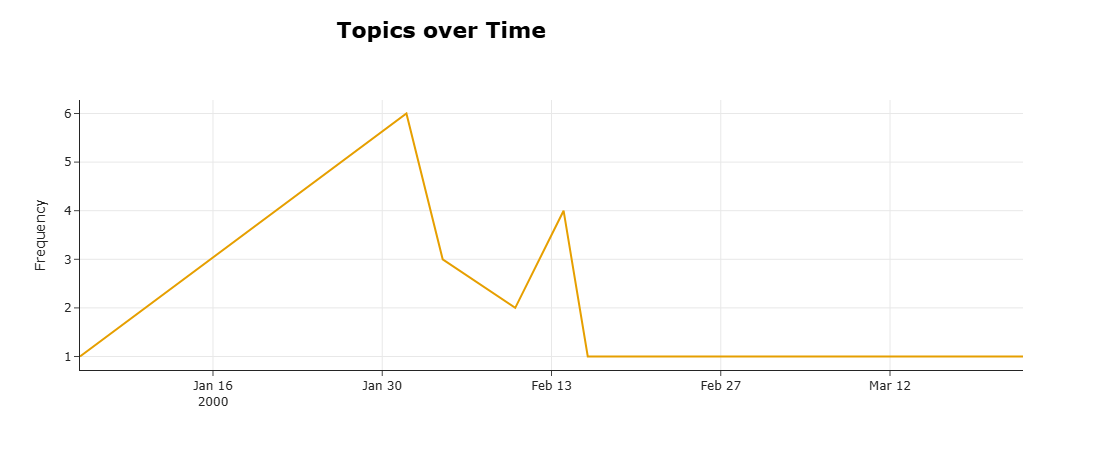

In [240]:
topics_to_show = [10]

model_ready_0.visualize_topics_over_time( # визуализируем интересующие нас темы
    topics_over_time_0,
    topics = topics_to_show
)

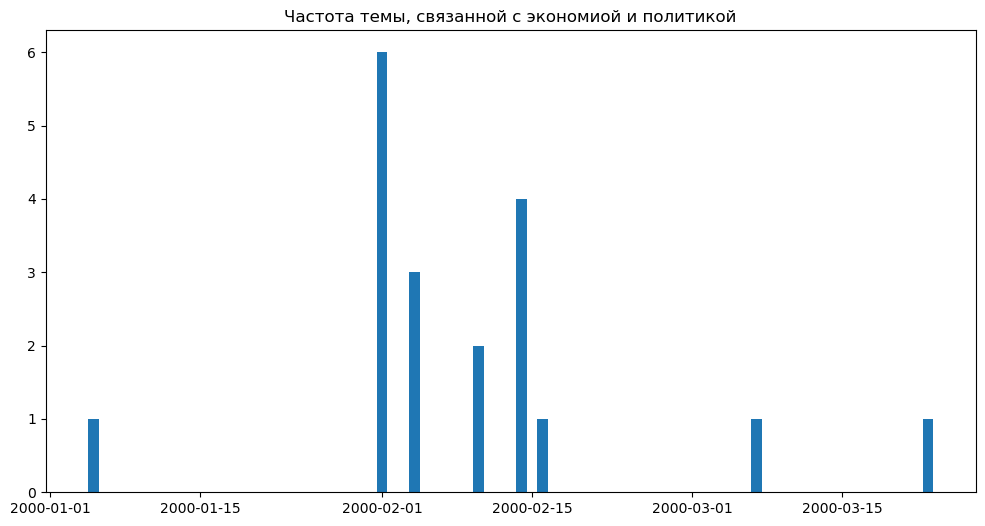

In [242]:
import matplotlib.pyplot as plt

topic_12_data = topics_over_time_0[topics_over_time_0["Topic"] == 10]

plt.figure(figsize=(12, 6))
plt.bar(topic_12_data["Timestamp"], topic_12_data["Frequency"], width = 1)
plt.title("Частота темы, связанной с экономиой и политикой")
plt.show()